# Resolution-Limited Control

Minimal simulation demonstrating that increasing control effort
may degrade effective observability and increase tracking error.

This notebook explores a simple dynamical model illustrating
a possible control–resolution trade-off.

## Concept

In many real systems stronger control improves performance only
up to a certain point.

Beyond some control intensity the system may become dominated by
noise, turbulence, or limited observability.

This notebook demonstrates a minimal mechanism where:

**control effort → resolution degradation → higher measurement noise**

The result is a finite limit on achievable control precision.

## Minimal Model

**State dynamics**

$$\dot{x} = -k x + u$$

**Resolution dynamics**

$$\dot{\ell} = \alpha |u| - (\ell - \ell_0)/\tau_\ell$$

**Observation**

$$y = x + \eta(\ell), \quad \eta(\ell) \sim \mathcal{N}(0, \sigma^2(\ell)), \quad \sigma(\ell) = \sigma_0 + \beta \ell$$

**Control**

$$u = \mathrm{clip}(K(r - y))$$

Stronger control increases $\ell$, which increases measurement noise.

## Model Parameters

To demonstrate the qualitative behavior of the system we choose a simple set of parameters.

### System dynamics

- **k** — natural relaxation rate of the system state  
  Controls how quickly the state returns to equilibrium in the absence of control.

### Resolution dynamics

- **ℓ₀** — baseline resolution scale  
  Represents the minimal distinguishable scale of the system when no control effort is applied.

- **α** — control–resolution coupling coefficient  
  Determines how strongly control effort increases the resolution scale.

- **τℓ** — resolution relaxation time  
  Describes how quickly the resolution scale returns to its baseline value after strong control actions.

### Observation noise

- **σ₀** — baseline measurement noise  
  Represents the intrinsic noise level of the measurement process.

- **β** — resolution noise amplification factor  
  Determines how strongly measurement noise increases when the resolution scale grows.

### Control parameters

- **K** — proportional control gain  
  Determines how aggressively the controller reacts to the observed error.

- **r** — target system state.

### Simulation parameters

- **dt** — integration timestep  
- **T** — total simulation time

These parameters are not intended to represent a specific physical system.  
They are chosen only to illustrate the qualitative effect of **resolution degradation under strong control effort**.

## Parameter values used in the simulation

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.35
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Base system
k = 1.0
l0 = 0.1
r = 1.0

# Resolution / noise settings
tau_l = 8
u_max = 2.5
sigma0 = 0.04

# Simulation settings
dt = 0.01
T = 30.0

# Sweep settings
alpha_values = [0.15, 0.3, 0.6]
beta_values = [0.4, 0.8, 1.2]
K_grid = np.linspace(0.1, 12.0, 60)

## Simulation model

In [3]:
def simulate(K, alpha, beta, seed=42):
    rng = np.random.default_rng(seed)
    n_steps = int(T / dt) + 1
    t = np.linspace(0.0, T, n_steps)
    x = np.zeros(n_steps)
    ell = np.zeros(n_steps)
    y = np.zeros(n_steps)
    u = np.zeros(n_steps)
    err = np.zeros(n_steps)
    sigma = np.zeros(n_steps)
    x[0] = 0.0
    ell[0] = l0
    for i in range(n_steps - 1):
        sigma[i] = sigma0 + beta * ell[i]
        y[i] = x[i] + rng.normal(0.0, sigma[i])
        u_raw = K * (r - y[i])
        u[i] = np.clip(u_raw, -u_max, u_max)
        err[i] = r - x[i]
        x_dot = -k * x[i] + u[i]
        x[i + 1] = x[i] + dt * x_dot
        ell_dot = alpha * abs(u[i]) - (ell[i] - l0) / tau_l
        ell[i + 1] = max(0.0, ell[i] + dt * ell_dot)
    sigma[-1] = sigma0 + beta * ell[-1]
    y[-1] = x[-1] + rng.normal(0.0, sigma[-1])
    u[-1] = np.clip(K * (r - y[-1]), -u_max, u_max)
    err[-1] = r - x[-1]
    return {"t": t, "x": x, "ell": ell, "y": y, "u": u, "err": err, "sigma": sigma}


def evaluate_gain(K, alpha, beta, n_runs=50, t_warmup=10.0):
    warmup_idx = int(t_warmup / dt)
    mean_abs_error_runs = []
    for seed in range(n_runs):
        res = simulate(K, alpha, beta, seed=seed)
        mean_abs_error_runs.append(np.mean(np.abs(res["err"][warmup_idx:])))
    return {
        "K": K,
        "mean_abs_error": np.mean(mean_abs_error_runs),
    }


def plot_trajectories(results_by_k, r):
    # Plot x(t), ℓ(t), |error| for several gains.
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for K, res in results_by_k.items():
        axes[0].plot(res["t"], res["x"], label=f"K={K}")
        axes[1].plot(res["t"], res["ell"], label=f"K={K}")
        axes[2].plot(res["t"], np.abs(res["err"]), label=f"K={K}")
    axes[0].axhline(r, linestyle="--", color="black", label="target r")
    axes[0].set_ylabel("state x(t)")
    axes[0].set_title("Example trajectories: weak / medium / aggressive control")
    axes[0].legend()
    axes[1].set_ylabel("resolution ℓ(t)")
    axes[1].legend()
    axes[2].set_ylabel("|error|")
    axes[2].set_xlabel("time")
    axes[2].legend()
    plt.tight_layout()
    plt.show()


def plot_sweep(alpha_values, beta_values, K_grid):
    # Sensitivity map: mean tracking error vs K for each (α, β).
    fig, axes = plt.subplots(len(alpha_values), len(beta_values), figsize=(12, 8), sharex=True, sharey=True)
    for i, a in enumerate(alpha_values):
        for j, b in enumerate(beta_values):
            errors = [evaluate_gain(K, a, b, n_runs=30)["mean_abs_error"] for K in K_grid]
            axes[i, j].plot(K_grid, errors)
            axes[i, j].set_title(f"α={a}, β={b}")
            axes[i, j].grid(True, alpha=0.35)
    for j in range(len(beta_values)):
        axes[-1, j].set_xlabel("control gain K")
    for i in range(len(alpha_values)):
        axes[i, 0].set_ylabel("mean tracking error")
    plt.tight_layout()
    plt.show()


## Example trajectories

We first compare a few controller gains in the time domain.

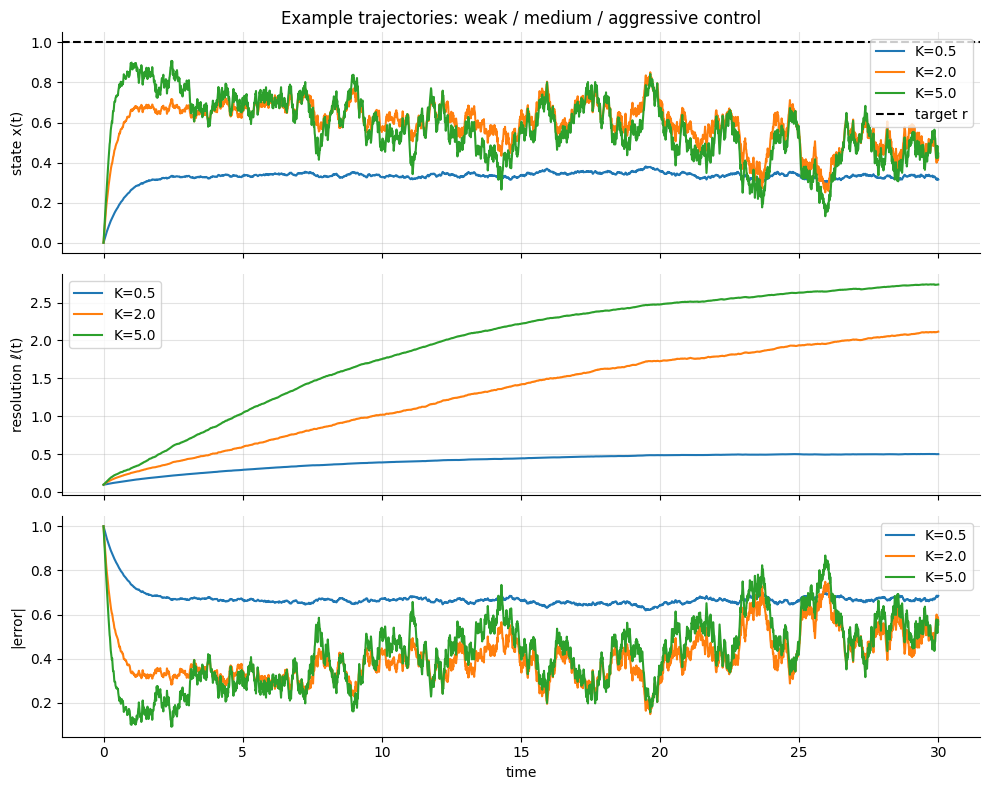

In [4]:
# One representative (α, β) for trajectory comparison
alpha_demo = 0.15
beta_demo = 0.8
K_values_demo = [0.5, 2.0, 5.0]

results_by_k = {
    K: simulate(K, alpha_demo, beta_demo, seed=42)
    for K in K_values_demo
}
plot_trajectories(results_by_k, r)

## Control gain sweep

We vary controller gain $K$ and measure the resulting tracking error
for different resolution-coupling parameters.

**Parameter meaning:**

- **α** — how strongly control effort increases the resolution scale
- **β** — how strongly resolution loss increases measurement noise

Tracking error is averaged after an initial transient period,
so the metric reflects steady-state control performance rather than startup behavior.

## Representative control-precision limit

The following parameter set illustrates the main effect of the model:
tracking error decreases with control gain only up to a finite optimum.
Beyond this point stronger control increases error due to resolution degradation.

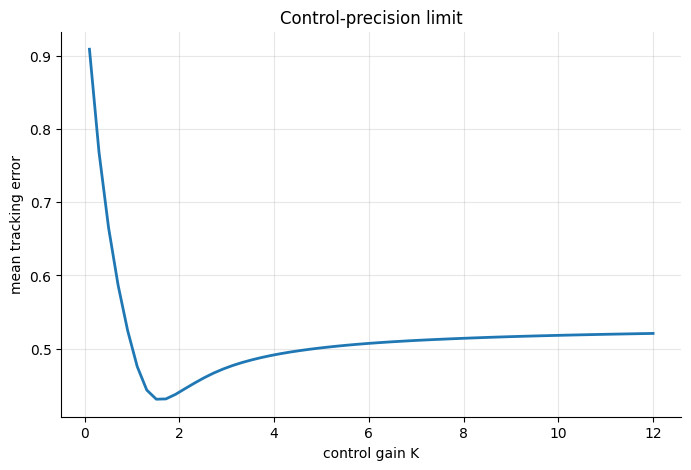

In [5]:
alpha = 0.15
beta = 0.8

metrics = [evaluate_gain(K, alpha=alpha, beta=beta, n_runs=50) for K in K_grid]

K_plot = np.array([m["K"] for m in metrics])
err_plot = np.array([m["mean_abs_error"] for m in metrics])

plt.figure(figsize=(8, 5))
plt.plot(K_plot, err_plot, linewidth=2)
plt.xlabel("control gain K")
plt.ylabel("mean tracking error")
plt.title("Control-precision limit")
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation:**

For small controller gains the system is under-actuated and tracking error is large.

Increasing gain improves tracking until resolution degradation begins to dominate.

Beyond this point the controller increasingly reacts to noise rather than the true state.

The matrix below shows how the effect depends on α and β (sensitivity map).

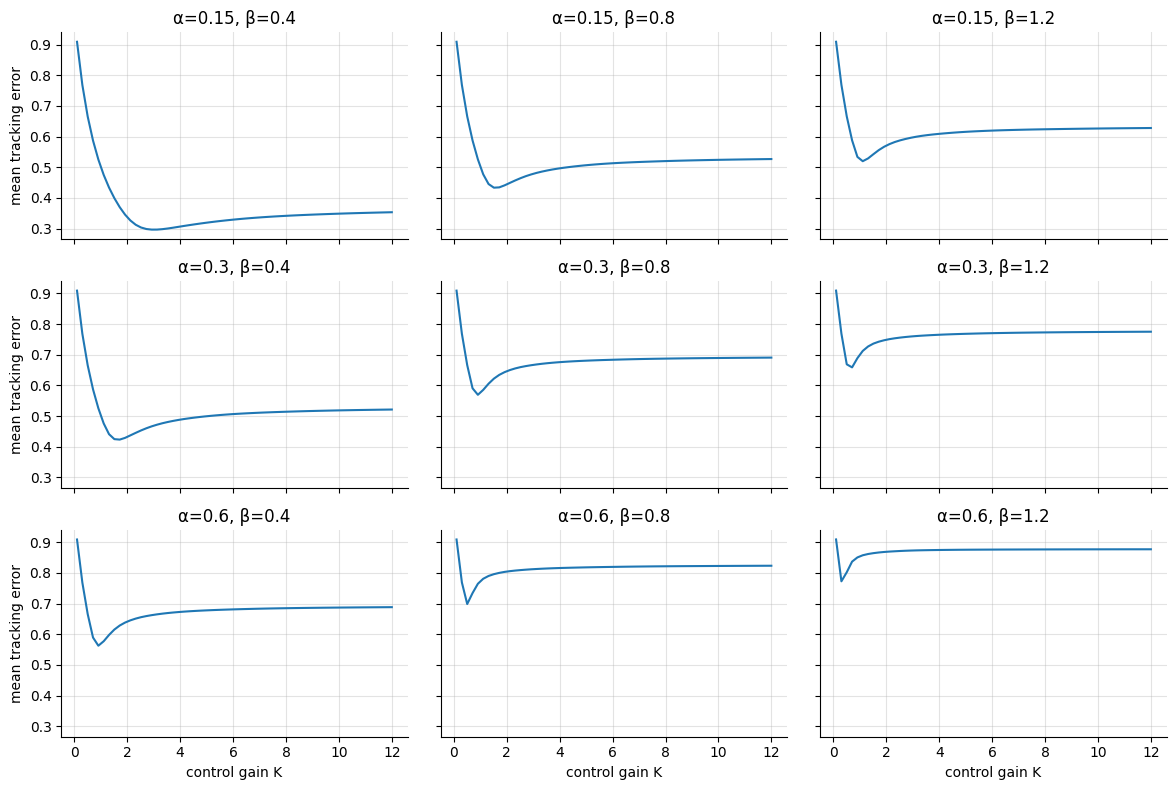

In [6]:
plot_sweep(alpha_values, beta_values, K_grid)

## Key takeaway

The simulation shows that increasing controller gain improves tracking
only up to a finite optimum.

Beyond that point, stronger control increases effective resolution loss,
amplifies noise, and degrades tracking performance.

This illustrates a possible **control-induced precision limit**
in systems where actuation degrades observability.

## Pulsed control: intermittent actuation

The continuous proportional controller applies effort at every timestep,
which steadily inflates the resolution scale $\ell$.

An alternative strategy is **pulsed (bang-bang) control**: apply a
fixed-amplitude pulse only when the observed error exceeds a threshold,
then wait.

**Pulsed controller logic:**

- If $|e_\text{obs}| > e_\text{thr}$: apply pulse $u = \pm A$ for duration $\Delta t_p$
- After each pulse: enter a refractory period $\Delta t_r$ with $u = 0$
- Otherwise: $u = 0$

The hypothesis is that pauses between pulses allow $\ell$ to partially
relax, preserving observability and potentially achieving better tracking
at lower average control power.

In [7]:
def simulate_pulsed(alpha, beta, pulse_amp=2.0, err_threshold=0.18,
                    pulse_duration=0.20, refractory_time=0.80,
                    negative_pulse=True, seed=42):
    rng = np.random.default_rng(seed)
    n_steps = int(T / dt) + 1
    t = np.linspace(0.0, T, n_steps)

    x   = np.zeros(n_steps)
    ell = np.zeros(n_steps)
    y   = np.zeros(n_steps)
    u   = np.zeros(n_steps)
    err = np.zeros(n_steps)
    sigma = np.zeros(n_steps)

    x[0]   = 0.0
    ell[0] = l0

    pulse_steps      = int(pulse_duration / dt)
    refractory_steps = int(refractory_time / dt)

    pulse_timer      = 0
    refractory_timer = 0
    current_sign     = 0.0

    for i in range(n_steps - 1):
        sigma[i] = sigma0 + beta * ell[i]
        y[i]     = x[i] + rng.normal(0.0, sigma[i])
        e_obs    = r - y[i]
        err[i]   = r - x[i]

        if pulse_timer > 0:
            u[i] = current_sign * pulse_amp
            pulse_timer -= 1
            if pulse_timer == 0:
                refractory_timer = refractory_steps
        elif refractory_timer > 0:
            u[i] = 0.0
            refractory_timer -= 1
        else:
            if e_obs > err_threshold:
                current_sign = +1.0
                u[i] = pulse_amp
                pulse_timer = pulse_steps - 1
            elif negative_pulse and e_obs < -err_threshold:
                current_sign = -1.0
                u[i] = -pulse_amp
                pulse_timer = pulse_steps - 1
            else:
                u[i] = 0.0

        x_dot   = -k * x[i] + u[i]
        x[i+1]  = x[i] + dt * x_dot
        ell_dot = alpha * abs(u[i]) - (ell[i] - l0) / tau_l
        ell[i+1] = max(0.0, ell[i] + dt * ell_dot)

    sigma[-1] = sigma0 + beta * ell[-1]
    y[-1]     = x[-1] + rng.normal(0.0, sigma[-1])
    err[-1]   = r - x[-1]
    return {"t": t, "x": x, "ell": ell, "y": y, "u": u, "err": err, "sigma": sigma}


WARMUP_IDX = int(10.0 / dt)

def compute_metrics(res):
    s = slice(WARMUP_IDX, None)
    return {
        "mean_abs_error": np.mean(np.abs(res["err"][s])),
        "mean_ell":       np.mean(res["ell"][s]),
        "mean_u2":        np.mean(res["u"][s] ** 2),
    }


def average_metrics(sim_fn, n_runs=50, **kw):
    vals = [compute_metrics(sim_fn(seed=seed, **kw)) for seed in range(n_runs)]
    return {k: np.mean([v[k] for v in vals]) for k in vals[0]}

### Single-run comparison

A direct time-domain overlay of the continuous and pulsed controllers
at one representative parameter set ($\alpha = 0.15$, $\beta = 0.8$).

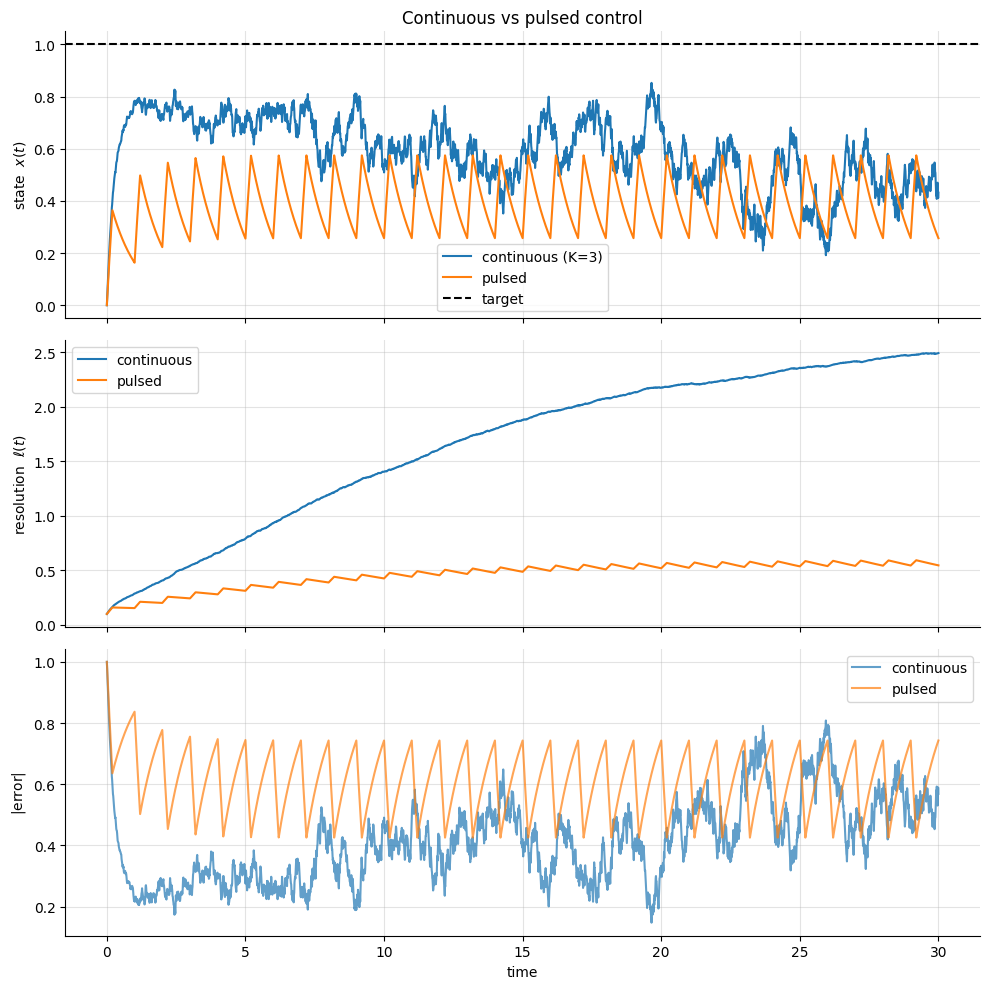

In [8]:
alpha_p, beta_p = 0.15, 0.8

res_cont  = simulate(K=3.0, alpha=alpha_p, beta=beta_p, seed=42)
res_pulse = simulate_pulsed(alpha=alpha_p, beta=beta_p,
                            pulse_amp=2.0, err_threshold=0.18,
                            pulse_duration=0.20, refractory_time=0.80, seed=42)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(res_cont["t"],  res_cont["x"],  label="continuous (K=3)")
axes[0].plot(res_pulse["t"], res_pulse["x"],  label="pulsed")
axes[0].axhline(r, ls="--", color="black", label="target")
axes[0].set_ylabel("state  $x(t)$")
axes[0].set_title("Continuous vs pulsed control")
axes[0].legend()

axes[1].plot(res_cont["t"],  res_cont["ell"],  label="continuous")
axes[1].plot(res_pulse["t"], res_pulse["ell"],  label="pulsed")
axes[1].set_ylabel("resolution  $\\ell(t)$")
axes[1].legend()

axes[2].plot(res_cont["t"],  np.abs(res_cont["err"]),  alpha=0.7, label="continuous")
axes[2].plot(res_pulse["t"], np.abs(res_pulse["err"]),  alpha=0.7, label="pulsed")
axes[2].set_ylabel("$|\\mathrm{error}|$")
axes[2].set_xlabel("time")
axes[2].legend()

plt.tight_layout()
plt.show()

### Aggregate A/B comparison

Metrics averaged over 50 independent noise realisations.

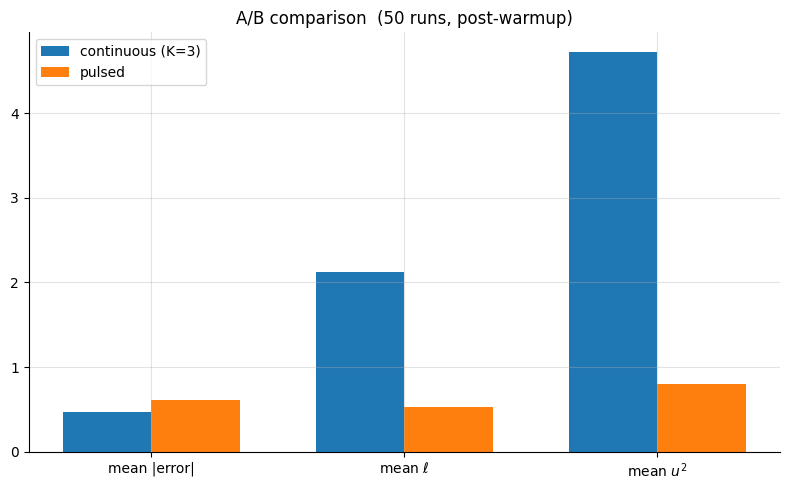

Continuous : {'mean_abs_error': np.float64(0.47407875150475953), 'mean_ell': np.float64(2.11811156785633), 'mean_u2': np.float64(4.7169030246818044)}
Pulsed     : {'mean_abs_error': np.float64(0.610173224513952), 'mean_ell': np.float64(0.5317965720520728), 'mean_u2': np.float64(0.7996001999000499)}


In [9]:
m_cont  = average_metrics(lambda seed, **_: simulate(K=3.0, alpha=alpha_p, beta=beta_p, seed=seed), n_runs=50)
m_pulse = average_metrics(simulate_pulsed, alpha=alpha_p, beta=beta_p,
                          pulse_amp=2.0, err_threshold=0.18,
                          pulse_duration=0.20, refractory_time=0.80, n_runs=50)

labels     = ["mean |error|", "mean $\\ell$", "mean $u^2$"]
cont_vals  = [m_cont["mean_abs_error"],  m_cont["mean_ell"],  m_cont["mean_u2"]]
pulse_vals = [m_pulse["mean_abs_error"], m_pulse["mean_ell"], m_pulse["mean_u2"]]

xpos  = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(xpos - width/2, cont_vals,  width, label="continuous (K=3)")
ax.bar(xpos + width/2, pulse_vals, width, label="pulsed")
ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_title("A/B comparison  (50 runs, post-warmup)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Continuous : {m_cont}")
print(f"Pulsed     : {m_pulse}")

### Pareto frontier: error vs control power

We sweep the gain $K$ for the continuous controller and the
tuple $(A,\; e_\text{thr},\; \Delta t_r)$ for the pulsed controller
to map both strategies in the **mean $u^2$ – mean |error|** plane.

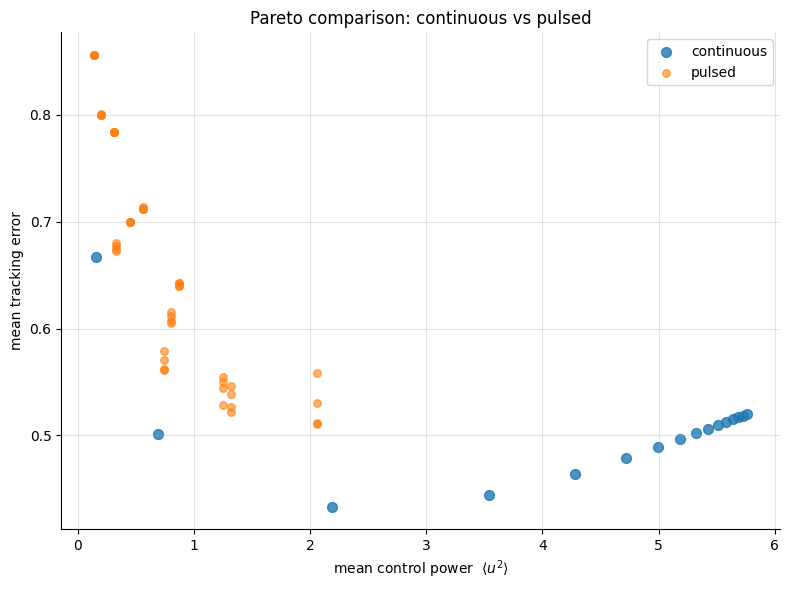

In [10]:
K_values_pareto = np.linspace(0.5, 8.0, 16)
cont_pts = []
for Kv in K_values_pareto:
    m = average_metrics(lambda seed, K=Kv: simulate(K=K, alpha=alpha_p, beta=beta_p, seed=seed), n_runs=30)
    cont_pts.append((m["mean_u2"], m["mean_abs_error"]))

pulse_amps   = [1.0, 1.5, 2.0, 2.5]
thresholds   = [0.10, 0.15, 0.20, 0.25]
refractories = [0.4, 0.8, 1.2]

pulse_pts = []
for amp in pulse_amps:
    for thr in thresholds:
        for ref in refractories:
            m = average_metrics(simulate_pulsed, alpha=alpha_p, beta=beta_p,
                                pulse_amp=amp, err_threshold=thr,
                                pulse_duration=0.20, refractory_time=ref, n_runs=20)
            pulse_pts.append((m["mean_u2"], m["mean_abs_error"]))

cont_pts  = np.array(cont_pts)
pulse_pts = np.array(pulse_pts)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cont_pts[:, 0],  cont_pts[:, 1],  s=50, alpha=0.8, label="continuous")
ax.scatter(pulse_pts[:, 0], pulse_pts[:, 1], s=30, alpha=0.6, label="pulsed")
ax.set_xlabel("mean control power  $\\langle u^2 \\rangle$")
ax.set_ylabel("mean tracking error")
ax.set_title("Pareto comparison: continuous vs pulsed")
ax.legend()
plt.tight_layout()
plt.show()

### When does pulsed control win?

The regime above ($\alpha = 0.15$, $\beta = 0.8$, $\tau_\ell = 8$)
represents weak resolution coupling and slow relaxation.
The continuous controller barely suffers from $\ell$-inflation, and the
pulsed controller cannot exploit its pauses because $\ell$ hardly
recovers during a 0.8 s refractory window.

The picture changes when the coupling is stronger and relaxation is faster:

| Parameter | Baseline | Favourable regime | Effect |
|-----------|:--------:|:-----------------:|--------|
| $\alpha$    |   0.15   |       0.50        | Control inflates $\ell$ 3× faster |
| $\beta$     |   0.80   |       1.50        | Noise penalty from high $\ell$ nearly doubled |
| $\tau_\ell$ |   8.0    |       2.0         | $\ell$ relaxes 4× faster — pauses become effective |

In this regime, one refractory period ($\Delta t_r = 0.8$ s) lets $\ell$
drop by ≈ 33 % ($e^{-0.8/2} \approx 0.67$) instead of ≈ 10 % before.

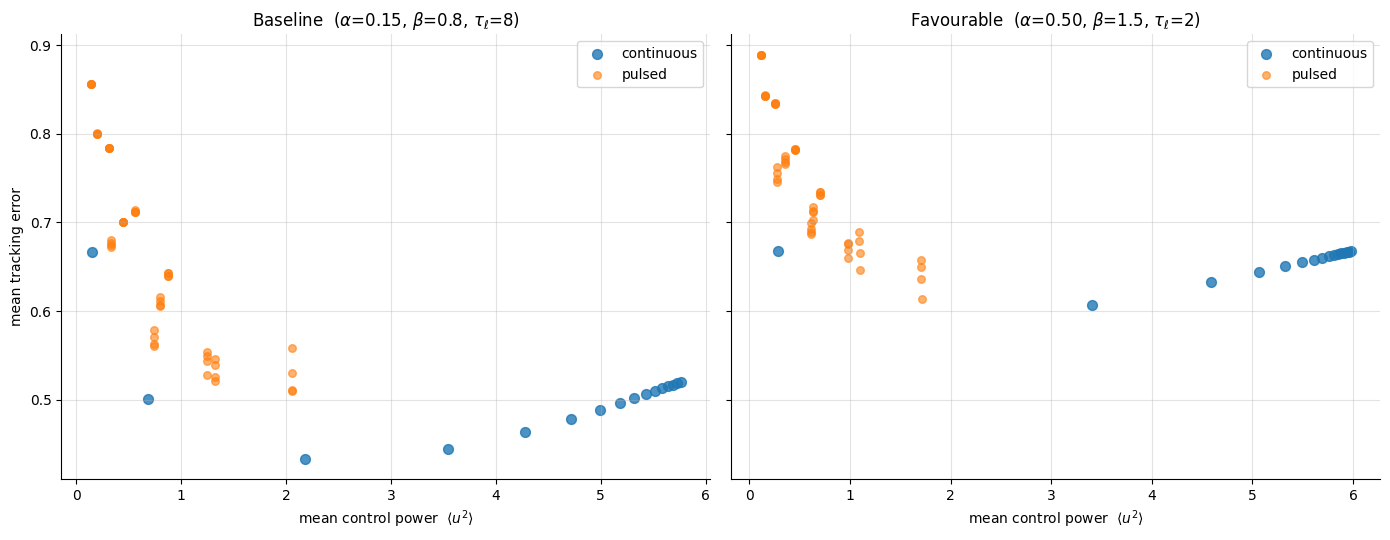

In [11]:
tau_l_saved = tau_l
tau_l = 2.0
alpha_f, beta_f = 0.5, 1.5

K_values_f = np.linspace(0.5, 8.0, 16)
cont_f = []
for Kv in K_values_f:
    m = average_metrics(
        lambda seed, K=Kv: simulate(K=K, alpha=alpha_f, beta=beta_f, seed=seed),
        n_runs=30,
    )
    cont_f.append((m["mean_u2"], m["mean_abs_error"]))

pulse_amps_f   = [1.0, 1.5, 2.0, 2.5]
thresholds_f   = [0.10, 0.15, 0.20, 0.25]
refractories_f = [0.4, 0.8, 1.2]

pulse_f = []
for amp in pulse_amps_f:
    for thr in thresholds_f:
        for ref in refractories_f:
            m = average_metrics(
                simulate_pulsed, alpha=alpha_f, beta=beta_f,
                pulse_amp=amp, err_threshold=thr,
                pulse_duration=0.15, refractory_time=ref, n_runs=20,
            )
            pulse_f.append((m["mean_u2"], m["mean_abs_error"]))

cont_f  = np.array(cont_f)
pulse_f = np.array(pulse_f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

axes[0].scatter(cont_pts[:, 0],  cont_pts[:, 1],  s=50, alpha=0.8, label="continuous")
axes[0].scatter(pulse_pts[:, 0], pulse_pts[:, 1], s=30, alpha=0.6, label="pulsed")
axes[0].set_xlabel("mean control power  $\\langle u^2 \\rangle$")
axes[0].set_ylabel("mean tracking error")
axes[0].set_title("Baseline  ($\\alpha$=0.15, $\\beta$=0.8, $\\tau_\\ell$=8)")
axes[0].legend()

axes[1].scatter(cont_f[:, 0],  cont_f[:, 1],  s=50, alpha=0.8, label="continuous")
axes[1].scatter(pulse_f[:, 0], pulse_f[:, 1], s=30, alpha=0.6, label="pulsed")
axes[1].set_xlabel("mean control power  $\\langle u^2 \\rangle$")
axes[1].set_title("Favourable  ($\\alpha$=0.50, $\\beta$=1.5, $\\tau_\\ell$=2)")
axes[1].legend()

plt.tight_layout()
plt.show()

tau_l = tau_l_saved

## Interpretation

In the baseline regime ($\alpha = 0.15$, $\beta = 0.8$, $\tau_\ell = 8$) the
continuous controller dominates: at any given control power it achieves
lower tracking error.  The resolution coupling is too weak and the
relaxation too slow for pauses to matter.

In the favourable regime ($\alpha = 0.5$, $\beta = 1.5$, $\tau_\ell = 2$)
the situation reverses.  Pulsed control points shift **below and to
the left** of the continuous curve — intermittent actuation achieves
lower error at the same or smaller control power.

The mechanism is straightforward: when resolution relaxation is fast
relative to the refractory period, each pause partially restores
observability.  The controller "sees better" between pulses, and the
next correction is more accurate.  The continuous controller never gets
this opportunity — it pays the full noise penalty at every timestep.

**Implication:**  The advantage of pulsed control is not universal — it
depends on the ratio $\Delta t_r / \tau_\ell$.  When relaxation is fast
enough for pauses to matter, intermittent actuation becomes the more
efficient strategy.

## Summary

This notebook demonstrates a minimal mechanism by which control effort
can degrade effective observability.

**Main ingredients:**
- bounded control
- dynamic resolution scale
- resolution-dependent measurement noise

**Main result (continuous control):**
- tracking improves only up to a finite control intensity
- beyond that point, stronger control can increase error

**Extension (pulsed control):**
- intermittent actuation allows the resolution scale to partially relax between pulses
- in the baseline regime, continuous control still dominates the Pareto frontier
- in the favourable regime (stronger coupling, faster relaxation), pulsed control dominates:
  lower tracking error at the same or smaller average control power

**Key parameter:** the ratio of refractory time to relaxation time
$\Delta t_r / \tau_\ell$ determines whether pauses are long enough
to restore observability.